## Modélisation - Comparaison de plusieurs algorithmes

Ce notebook compare différents modèles de Machine Learning pour prédire la fraude :
- **Régression logistique**
- **K-Nearest Neighbors (KNN)**
- **Arbres de décision et Forêts aléatoires**
- **Boosting** (AdaBoost / Gradient Boosting, XG Boost)

Pour chaque modèle :
1. Chargement des données preprocessées
2. Entraînement avec optimisation des hyperparamètres (GridSearchCV)
3. Évaluation sur validation (F1-score)
4. Prédictions sur test
5. Export CSV au format Kaggle (`customer_id`, `target_is_fraud`)
6. Export au format pickel

In [2]:
# Imports nécessaires
import pandas as pd
import numpy as np
import pickle
import json
import os
from datetime import datetime
import glob
import shap
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.metrics import f1_score, classification_report, confusion_matrix, roc_auc_score
from xgboost import XGBClassifier

import warnings
warnings.filterwarnings('ignore')

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("Imports terminés")

C:\Users\maell\AppData\Roaming\Python\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Imports terminés


### 1. Chargement des données preprocessées

On charge les données qui ont été preprocessées dans le notebook `Preprocessing_final.ipynb`.

In [3]:
# Chemins vers les données preprocessées
TRAIN_PREPROCESSED_PATH = "../data/train_preprocessed_v2_V4.csv"
TEST_PREPROCESSED_PATH = "../data/test_preprocessed_v2_V4.csv"
# Chemin vers le fichier test ORIGINAL pour récupérer les customer_id non modifiés
TEST_ORIGINAL_PATH = "../data/kaggle_b2_fraud_test_v4.csv"

# Chargement
train = pd.read_csv(TRAIN_PREPROCESSED_PATH)
test = pd.read_csv(TEST_PREPROCESSED_PATH)

print(f"Train shape : {train.shape}")
print(f"Test shape  : {test.shape}")
print(f"\nColonnes train : {train.columns.tolist()[:10]}...")

# Séparation X / y
ID_COL = "customer_id"
TARGET_COL = "target_is_fraud"

X_train = train.drop(columns=[ID_COL, TARGET_COL])
y_train = train[TARGET_COL]
X_test = test.drop(columns=[ID_COL])


try:
    test_original = pd.read_csv(TEST_ORIGINAL_PATH)
    customer_ids_test = test_original[ID_COL]
    print(f"\nCustomer IDs chargés depuis le fichier original : {len(customer_ids_test)} IDs")
    print(f"   Exemple : {customer_ids_test.iloc[0]}")
except FileNotFoundError:
    print(f"\n Fichier original non trouvé, utilisation des IDs du fichier preprocessé")
    customer_ids_test = test[ID_COL]

print(f"\nX_train shape : {X_train.shape}")
print(f"y_train shape : {y_train.shape}")
print(f"X_test shape  : {X_test.shape}")
print(f"\nDistribution de la cible (train) :")
print(y_train.value_counts())
print(f"\nTaux de fraude : {y_train.mean():.4f}")

Train shape : (160000, 50)
Test shape  : (40000, 49)

Colonnes train : ['customer_id', 'target_is_fraud', 'feature_0', 'feature_1', 'feature_2', 'feature_3', 'feature_4', 'feature_5', 'feature_6', 'feature_7']...

Customer IDs chargés depuis le fichier original : 40000 IDs
   Exemple : CUST_E5RX1BC9II

X_train shape : (160000, 48)
y_train shape : (160000,)
X_test shape  : (40000, 48)

Distribution de la cible (train) :
target_is_fraud
0    146223
1     13777
Name: count, dtype: int64

Taux de fraude : 0.0861


### 1.5. Fonction helper pour exporter au format Kaggle

Fonction pour garantir que les exports sont exactement au format attendu par Kaggle.

In [4]:
def export_submission_kaggle(customer_ids, predictions, filename):
    
    submission = pd.DataFrame({
        'customer_id': customer_ids,  
        'target_is_fraud': predictions 
    })
    
    submission['customer_id'] = submission['customer_id'].astype(str)
    
    submission['target_is_fraud'] = submission['target_is_fraud'].astype(int)
    
    # Export
    filepath = f"../Prédiction/{filename}"
    submission.to_csv(filepath, index=False)
    
    print(f"Exporté : {filename}")
    print(f"Shape : {submission.shape}")
    print(f"Colonnes : {submission.columns.tolist()}")
    print(f"Distribution prédictions : {submission['target_is_fraud'].value_counts().to_dict()}")
    print(f"Exemple customer_id : {submission['customer_id'].iloc[0]}")
    
    return submission

print("Fonction export_submission_kaggle définie")

Fonction export_submission_kaggle définie


### 2. Split train/validation

On garde une partie des données d'entraînement pour la validation et l'optimisation des hyperparamètres.

In [5]:
# Split train/validation (80/20)
X_train_split, X_val, y_train_split, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train  
)

print(f"X_train_split : {X_train_split.shape}")
print(f"X_val         : {X_val.shape}")
print(f"\nTaux de fraude train : {y_train_split.mean():.4f}")
print(f"Taux de fraude val   : {y_val.mean():.4f}")

X_train_split : (128000, 48)
X_val         : (32000, 48)

Taux de fraude train : 0.0861
Taux de fraude val   : 0.0861


### 3. Modèle 1 : Régression Logistique

Régression logistique avec optimisation des hyperparamètres via GridSearchCV.

In [23]:
# Définition de la grille d'hyperparamètres
param_grid_lr = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear', 'saga'],
    'max_iter': [1000]
}

# GridSearchCV avec F1-score comme métrique
lr = LogisticRegression(random_state=42, class_weight='balanced')
grid_search_lr = GridSearchCV(
    lr,
    param_grid_lr,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

print(" Recherche des meilleurs hyperparamètres pour Régression Logistique...")
grid_search_lr.fit(X_train_split, y_train_split)

print(f"\nMeilleurs paramètres : {grid_search_lr.best_params_}")
print(f"Meilleur F1-score (CV) : {grid_search_lr.best_score_:.4f}")

# Prédictions sur validation
y_val_pred_lr = grid_search_lr.predict(X_val)
f1_val_lr = f1_score(y_val, y_val_pred_lr)

print(f"\nF1-score sur validation : {f1_val_lr:.4f}")
print("\nRapport de classification :")
print(classification_report(y_val, y_val_pred_lr))

# Prédictions sur test
y_test_pred_lr = grid_search_lr.predict(X_test)

# Export CSV 
submission_lr = export_submission_kaggle(
    customer_ids_test,
    y_test_pred_lr,
    "submission_logistic_regression.csv"
)

 Recherche des meilleurs hyperparamètres pour Régression Logistique...
Fitting 5 folds for each of 20 candidates, totalling 100 fits

Meilleurs paramètres : {'C': 0.01, 'max_iter': 1000, 'penalty': 'l2', 'solver': 'saga'}
Meilleur F1-score (CV) : 0.3684

F1-score sur validation : 0.3677

Rapport de classification :
              precision    recall  f1-score   support

           0       0.97      0.77      0.86     29245
           1       0.24      0.78      0.37      2755

    accuracy                           0.77     32000
   macro avg       0.61      0.77      0.61     32000
weighted avg       0.91      0.77      0.82     32000

Exporté : submission_logistic_regression.csv
Shape : (40000, 2)
Colonnes : ['customer_id', 'target_is_fraud']
Distribution prédictions : {0: 28841, 1: 11159}
Exemple customer_id : CUST_E5RX1BC9II


In [ ]:
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

# Sauvegarder le modèle de régression logistique
model_path = f"../Models/logistic_regression_{timestamp}.pkl"
with open(model_path, "wb") as file:
    pickle.dump(grid_search_lr.best_estimator_, file)
print("Modèle régression logistique sauvegardé ->", model_path)

# Sauvegarder les paramètres
params_path = f"../Models/logistic_params_{timestamp}.json"
with open(params_path, "w") as file:
    json.dump(grid_search_lr.best_params_, file, indent=4)
print("Paramètres sauvegardés ->", params_path)

# Résumé texte
summary_path = f"../Models/logistic_summary_{timestamp}.txt"
with open(summary_path, "w") as file:
    file.write("RÉGRESSION LOGISTIQUE\n")
    file.write("="*30 + "\n")
    file.write(f"Best params: {grid_search_lr.best_params_}\n")
    file.write(f"Best CV score: {grid_search_lr.best_score_:.4f}\n")
    file.write(f"Validation F1: {f1_val_lr:.4f}\n")
    file.write(f"\nRapport de classification:\n")
    file.write(f"Précision classe 1: 0.24\n")
    file.write(f"Recall classe 1: 0.78\n")
    file.write(f"F1-score classe 1: 0.37\n")
print("Résumé sauvegardé ->", summary_path)

Modèle régression logistique sauvegardé -> ../Models/logistic_regression_20260303_133505.pkl
Paramètres sauvegardés -> ../Models/logistic_params_20260303_133505.json
Résumé sauvegardé -> ../Models/logistic_summary_20260303_133505.txt


### 4. Modèle 2 : K-Nearest Neighbors (KNN)

KNN avec optimisation du nombre de voisins et de la métrique de distance.

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
param_grid_knn = {
    'n_neighbors': [3, 5, 7, 9, 11, 15],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski']
}

knn = KNeighborsClassifier()
grid_search_knn = RandomizedSearchCV(
    knn,
    param_grid_knn,
    n_iter=20,  
    cv=3, 
    scoring='f1',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

print("Recherche des meilleurs hyperparamètres pour KNN...")
grid_search_knn.fit(X_train_split, y_train_split)

print(f"\nMeilleurs paramètres : {grid_search_knn.best_params_}")
print(f"Meilleur F1-score (CV) : {grid_search_knn.best_score_:.4f}")

# Prédictions sur validation
y_val_pred_knn = grid_search_knn.predict(X_val)
f1_val_knn = f1_score(y_val, y_val_pred_knn)

print(f"\nF1-score sur validation : {f1_val_knn:.4f}")
print("\nRapport de classification :")
print(classification_report(y_val, y_val_pred_knn))

# Prédictions sur test
y_test_pred_knn = grid_search_knn.predict(X_test)

# Export CSV 
submission_knn = export_submission_kaggle(
    customer_ids_test,
    y_test_pred_knn,
    "submission_knn.csv"
)

Recherche des meilleurs hyperparamètres pour KNN...
Fitting 3 folds for each of 20 candidates, totalling 60 fits

Meilleurs paramètres : {'weights': 'uniform', 'n_neighbors': 3, 'metric': 'euclidean'}
Meilleur F1-score (CV) : 0.1982


  File "C:\Users\maell\AppData\Roaming\Python\Python311\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\Program Files\Python311\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Program Files\Python311\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "c:\Program Files\Python311\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,
                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^



F1-score sur validation : 0.2077

Rapport de classification :
              precision    recall  f1-score   support

           0       0.92      0.98      0.95     29245
           1       0.38      0.14      0.21      2755

    accuracy                           0.91     32000
   macro avg       0.65      0.56      0.58     32000
weighted avg       0.88      0.91      0.89     32000

Exporté : submission_knn.csv
Shape : (40000, 2)
Colonnes : ['customer_id', 'target_is_fraud']
Distribution prédictions : {0: 38726, 1: 1274}
Exemple customer_id : CUST_E5RX1BC9II


In [ ]:
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

# Sauvegarder le modèle KNN
model_path = f"../Models/knn_{timestamp}.pkl"
with open(model_path, "wb") as file:
    pickle.dump(grid_search_knn.best_estimator_, file)
print("Modèle KNN sauvegardé ->", model_path)

# Sauvegarder les paramètres
params_path = f"../Models/knn_params_{timestamp}.json"
with open(params_path, "w") as file:
    json.dump(grid_search_knn.best_params_, file, indent=4)
print("Paramètres KNN sauvegardés ->", params_path)

# Résumé texte
summary_path = f"../Models/knn_summary_{timestamp}.txt"
with open(summary_path, "w") as file:
    file.write("K-NEAREST NEIGHBORS\n")
    file.write("="*30 + "\n")
    file.write(f"Best params: {grid_search_knn.best_params_}\n")
    file.write(f"Best CV score: {grid_search_knn.best_score_:.4f}\n")
    file.write(f"Validation F1: {f1_val_knn:.4f}\n")
    file.write(f"\nRapport de classification:\n")
    file.write(f"Précision classe 1: 0.38\n")
    file.write(f"Recall classe 1: 0.14\n")
    file.write(f"F1-score classe 1: 0.21\n")
print("Résumé KNN sauvegardé ->", summary_path)

Modèle KNN sauvegardé -> ../Models/knn_20260303_133555.pkl
Paramètres KNN sauvegardés -> ../Models/knn_params_20260303_133555.json
Résumé KNN sauvegardé -> ../Models/knn_summary_20260303_133555.txt


### 5. Modèle 3 : Arbre de Décision

Arbre de décision avec optimisation de la profondeur et autres hyperparamètres.

In [ ]:
# Définition de la grille d'hyperparamètres
param_grid_dt = {
    'max_depth': [5, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}

# GridSearchCV avec F1-score comme métrique
dt = DecisionTreeClassifier(random_state=42, class_weight='balanced')
grid_search_dt = GridSearchCV(
    dt,
    param_grid_dt,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

print("Recherche des meilleurs hyperparamètres pour Arbre de Décision...")
grid_search_dt.fit(X_train_split, y_train_split)

print(f"\nMeilleurs paramètres : {grid_search_dt.best_params_}")
print(f"Meilleur F1-score (CV) : {grid_search_dt.best_score_:.4f}")

# Prédictions sur validation
y_val_pred_dt = grid_search_dt.predict(X_val)
f1_val_dt = f1_score(y_val, y_val_pred_dt)

print(f"\nF1-score sur validation : {f1_val_dt:.4f}")
print("\nRapport de classification :")
print(classification_report(y_val, y_val_pred_dt))

# Prédictions sur test
y_test_pred_dt = grid_search_dt.predict(X_test)

# Export CSV 
submission_dt = export_submission_kaggle(
    customer_ids_test,
    y_test_pred_dt,
    "submission_decision_tree.csv"
)

Recherche des meilleurs hyperparamètres pour Arbre de Décision...
Fitting 5 folds for each of 90 candidates, totalling 450 fits

Meilleurs paramètres : {'criterion': 'gini', 'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2}
Meilleur F1-score (CV) : 0.3364

F1-score sur validation : 0.3438

Rapport de classification :
              precision    recall  f1-score   support

           0       0.97      0.77      0.86     29245
           1       0.23      0.72      0.34      2755

    accuracy                           0.76     32000
   macro avg       0.60      0.74      0.60     32000
weighted avg       0.90      0.76      0.81     32000

Exporté : submission_decision_tree.csv
Shape : (40000, 2)
Colonnes : ['customer_id', 'target_is_fraud']
Distribution prédictions : {0: 29147, 1: 10853}
Exemple customer_id : CUST_E5RX1BC9II


In [ ]:
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

# Sauvegarder le modèle Arbre de Décision
model_path = f"../Models/decision_tree_{timestamp}.pkl"
with open(model_path, "wb") as file:
    pickle.dump(grid_search_dt.best_estimator_, file)
print("Modèle Arbre de Décision sauvegardé ->", model_path)

# Sauvegarder les paramètres
params_path = f"../Models/decision_tree_params_{timestamp}.json"
with open(params_path, "w") as file:
    json.dump(grid_search_dt.best_params_, file, indent=4)
print("Paramètres Arbre de Décision sauvegardés ->", params_path)

# Résumé texte
summary_path = f"../Models/decision_tree_summary_{timestamp}.txt"
with open(summary_path, "w") as file:
    file.write("ARBRE DE DÉCISION\n")
    file.write("="*30 + "\n")
    file.write(f"Best params: {grid_search_dt.best_params_}\n")
    file.write(f"Best CV score: {grid_search_dt.best_score_:.4f}\n")
    file.write(f"Validation F1: {f1_val_dt:.4f}\n")
    file.write(f"\nRapport de classification:\n")
    file.write(f"Précision classe 1: 0.23\n")
    file.write(f"Recall classe 1: 0.72\n")
    file.write(f"F1-score classe 1: 0.34\n")
print("Résumé Arbre de Décision sauvegardé ->", summary_path)

Modèle Arbre de Décision sauvegardé -> ../Models/decision_tree_20260303_133639.pkl
Paramètres Arbre de Décision sauvegardés -> ../Models/decision_tree_params_20260303_133639.json
Résumé Arbre de Décision sauvegardé -> ../Models/decision_tree_summary_20260303_133639.txt


### 6. Modèle 4 : Random Forest

Forêt aléatoire avec optimisation du nombre d'arbres, profondeur, etc.

In [ ]:
# Définition de la grille d'hyperparamètres
param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 'log2']
}

# GridSearchCV avec F1-score comme métrique
rf = RandomForestClassifier(random_state=42, class_weight='balanced', n_jobs=-1)
grid_search_rf = GridSearchCV(
    rf,
    param_grid_rf,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

print("Recherche des meilleurs hyperparamètres pour Random Forest...")
grid_search_rf.fit(X_train_split, y_train_split)

print(f"\nMeilleurs paramètres : {grid_search_rf.best_params_}")
print(f"Meilleur F1-score (CV) : {grid_search_rf.best_score_:.4f}")

# Prédictions sur validation
y_val_pred_rf = grid_search_rf.predict(X_val)
f1_val_rf = f1_score(y_val, y_val_pred_rf)

print(f"\nF1-score sur validation : {f1_val_rf:.4f}")
print("\nRapport de classification :")
print(classification_report(y_val, y_val_pred_rf))

# Prédictions sur test
y_test_pred_rf = grid_search_rf.predict(X_test)

# Export CSV 
submission_rf = export_submission_kaggle(
    customer_ids_test,
    y_test_pred_rf,
    "submission_random_forest.csv"
)

Recherche des meilleurs hyperparamètres pour Random Forest...
Fitting 5 folds for each of 72 candidates, totalling 360 fits

Meilleurs paramètres : {'max_depth': 20, 'max_features': 'log2', 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}
Meilleur F1-score (CV) : 0.3900

F1-score sur validation : 0.3807

Rapport de classification :
              precision    recall  f1-score   support

           0       0.94      0.94      0.94     29245
           1       0.37      0.39      0.38      2755

    accuracy                           0.89     32000
   macro avg       0.66      0.67      0.66     32000
weighted avg       0.89      0.89      0.89     32000

Exporté : submission_random_forest.csv
Shape : (40000, 2)
Colonnes : ['customer_id', 'target_is_fraud']
Distribution prédictions : {0: 36319, 1: 3681}
Exemple customer_id : CUST_E5RX1BC9II


In [ ]:
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

# Sauvegarder le modèle
model_path = f"../Models/random_forest_{timestamp}.pkl"
with open(model_path, "wb") as file:
    pickle.dump(grid_search_rf.best_estimator_, file)
print("Modèle sauvegardé ->", model_path)

# Sauvegarder les paramètres
params_path = f"../Models/params_{timestamp}.json"
with open(params_path, "w") as file:
    json.dump(grid_search_rf.best_params_, file, indent=4)
print("Paramètres sauvegardés ->", params_path)

# Résumé texte
summary_path = f"../Models/summary_{timestamp}.txt"
with open(summary_path, "w") as file:
    file.write(f"Best params: {grid_search_rf.best_params_}\n")
    file.write(f"Best CV score: {grid_search_rf.best_score_:.4f}\n")
    file.write(f"Validation F1: {f1_val_rf:.4f}\n")
print("Résumé sauvegardé ->", summary_path)

Modèle sauvegardé -> ../Models/random_forest_20260303_133417.pkl
Paramètres sauvegardés -> ../Models/params_20260303_133417.json
Résumé sauvegardé -> ../Models/summary_20260303_133417.txt


### 7. Modèle 5 : AdaBoost

AdaBoost avec optimisation du nombre d'estimateurs et du learning rate.

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

param_grid_adaboost = {
    'n_estimators': [50, 100, 150],           
    'learning_rate': [0.05, 0.1, 0.2, 0.5],   
    'estimator': [                            
        DecisionTreeClassifier(max_depth=1, random_state=42),
        DecisionTreeClassifier(max_depth=2, random_state=42),
    ],
}

adaboost = AdaBoostClassifier(random_state=42)

grid_search_adaboost = RandomizedSearchCV(
    adaboost,
    param_distributions=param_grid_adaboost,
    n_iter=15,        
    cv=3,             
    scoring='f1',
    n_jobs=-1,
    random_state=42,
    verbose=1,
)

print("Recherche des meilleurs hyperparamètres pour AdaBoost...")
grid_search_adaboost.fit(X_train_split, y_train_split)

print(f"\nMeilleurs paramètres : {grid_search_adaboost.best_params_}")
print(f"Meilleur F1-score (CV) : {grid_search_adaboost.best_score_:.4f}")

# Prédictions sur validation
y_val_pred_adaboost = grid_search_adaboost.predict(X_val)
f1_val_adaboost = f1_score(y_val, y_val_pred_adaboost)

print(f"\nF1-score sur validation : {f1_val_adaboost:.4f}")
print("\nRapport de classification :")
print(classification_report(y_val, y_val_pred_adaboost))

# Prédictions sur test
y_test_pred_adaboost = grid_search_adaboost.predict(X_test)

# Export CSV 
submission_adaboost = export_submission_kaggle(
    customer_ids_test,
    y_test_pred_adaboost,
    "submission_adaboost.csv"
)

Recherche des meilleurs hyperparamètres pour AdaBoost (version rapide)...
Fitting 3 folds for each of 15 candidates, totalling 45 fits

Meilleurs paramètres : {'n_estimators': 150, 'learning_rate': 0.5, 'estimator': DecisionTreeClassifier(max_depth=1, random_state=42)}
Meilleur F1-score (CV) : 0.2931

F1-score sur validation : 0.2736

Rapport de classification :
              precision    recall  f1-score   support

           0       0.93      0.99      0.96     29245
           1       0.64      0.17      0.27      2755

    accuracy                           0.92     32000
   macro avg       0.78      0.58      0.62     32000
weighted avg       0.90      0.92      0.90     32000

Exporté : submission_adaboost.csv
Shape : (40000, 2)
Colonnes : ['customer_id', 'target_is_fraud']
Distribution prédictions : {0: 39061, 1: 939}
Exemple customer_id : CUST_E5RX1BC9II


In [14]:
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

# Sauvegarder le modèle AdaBoost
model_path = f"../Models/adaboost_{timestamp}.pkl"
with open(model_path, "wb") as file:
    pickle.dump(grid_search_adaboost.best_estimator_, file)
print("Modèle AdaBoost sauvegardé ->", model_path)

# Sauvegarder les paramètres
params_path = f"../Models/adaboost_params_{timestamp}.json"
with open(params_path, "w") as file:

    params = grid_search_adaboost.best_params_.copy()
    if 'estimator' in params:
        estimator_desc = str(params['estimator'])
        params['estimator'] = estimator_desc
    json.dump(params, file, indent=4)
print("Paramètres AdaBoost sauvegardés ->", params_path)

# Résumé texte
summary_path = f"../Models/adaboost_summary_{timestamp}.txt"
with open(summary_path, "w") as file:
    file.write(f"Meilleurs paramètres: {grid_search_adaboost.best_params_}\n")
    file.write(f"Meilleur F1-score (CV): {grid_search_adaboost.best_score_:.4f}\n")
    file.write(f"F1-score validation: {f1_val_adaboost:.4f}\n")
    file.write(f"\nDistribution prédictions: 939 fraudes sur 40000\n")
print("Résumé AdaBoost sauvegardé ->", summary_path)

Modèle AdaBoost sauvegardé -> ../Models/adaboost_20260304_222252.pkl
Paramètres AdaBoost sauvegardés -> ../Models/adaboost_params_20260304_222252.json
Résumé AdaBoost sauvegardé -> ../Models/adaboost_summary_20260304_222252.txt


### 8. Modèle 6 : Gradient Boosting

Gradient Boosting avec optimisation des hyperparamètres.

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

param_dist_gb = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.05, 0.1, 0.2],
    'max_depth': [2, 3, 4],
    'subsample': [0.8, 1.0],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5],
    'max_features': [None, 'sqrt'],
}

gb = GradientBoostingClassifier(random_state=42)

grid_search_gb = RandomizedSearchCV(
    gb,
    param_distributions=param_dist_gb,
    n_iter=20,      
    cv=3,           
    scoring='f1',
    n_jobs=-1,
    random_state=42,
    verbose=1,
)

print("Recherche des meilleurs hyperparamètres pour Gradient Boosting...")
grid_search_gb.fit(X_train_split, y_train_split)

print(f"\nMeilleurs paramètres : {grid_search_gb.best_params_}")
print(f"Meilleur F1-score (CV) : {grid_search_gb.best_score_:.4f}")

# Prédictions sur validation
y_val_pred_gb = grid_search_gb.predict(X_val)
f1_val_gb = f1_score(y_val, y_val_pred_gb)

print(f"\nF1-score sur validation : {f1_val_gb:.4f}")
print("\nRapport de classification :")
print(classification_report(y_val, y_val_pred_gb))

# Prédictions sur test
y_test_pred_gb = grid_search_gb.predict(X_test)

# Export CSV 
submission_gb = export_submission_kaggle(
    customer_ids_test,
    y_test_pred_gb,
    "submission_gradient_boosting.csv"
)

Recherche des meilleurs hyperparamètres pour Gradient Boosting (version rapide)...
Fitting 3 folds for each of 20 candidates, totalling 60 fits

Meilleurs paramètres : {'subsample': 0.8, 'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 5, 'max_features': None, 'max_depth': 3, 'learning_rate': 0.2}
Meilleur F1-score (CV) : 0.3148

F1-score sur validation : 0.2903

Rapport de classification :
              precision    recall  f1-score   support

           0       0.93      0.99      0.96     29245
           1       0.59      0.19      0.29      2755

    accuracy                           0.92     32000
   macro avg       0.76      0.59      0.62     32000
weighted avg       0.90      0.92      0.90     32000

Exporté : submission_gradient_boosting.csv
Shape : (40000, 2)
Colonnes : ['customer_id', 'target_is_fraud']
Distribution prédictions : {0: 38848, 1: 1152}
Exemple customer_id : CUST_E5RX1BC9II


In [7]:
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

# Modèle
model_path = f"../Models/gradient_boosting_{timestamp}.pkl"
with open(model_path, "wb") as file:
    pickle.dump(grid_search_gb.best_estimator_, file)
print("Modèle Gradient Boosting sauvegardé ->", model_path)

# Paramètres
params_path = f"../Models/gradient_boosting_params_{timestamp}.json"
with open(params_path, "w") as file:
    json.dump(grid_search_gb.best_params_, file, indent=4)
print("Paramètres sauvegardés ->", params_path)

# Résumé
summary_path = f"../Models/gradient_boosting_summary_{timestamp}.txt"
with open(summary_path, "w") as file:
    file.write(f"Best params: {grid_search_gb.best_params_}\n")
    file.write(f"Best CV score: {grid_search_gb.best_score_:.4f}\n")
    file.write(f"Validation F1: {f1_val_gb:.4f}\n")
print("Résumé sauvegardé ->", summary_path)

Modèle Gradient Boosting sauvegardé -> ../Models/gradient_boosting_20260305_151258.pkl
Paramètres sauvegardés -> ../Models/gradient_boosting_params_20260305_151258.json
Résumé sauvegardé -> ../Models/gradient_boosting_summary_20260305_151258.txt


### 9. Modèle 7 : XGBoost 

XGBoost avec une recherche d’hyperparamètres raisonnable via `RandomizedSearchCV`, pour un bon compromis entre temps de calcul et performance. On utilise `scale_pos_weight` pour tenir compte du déséquilibre de classes.

#### 9.a XGBoost 


In [25]:
from sklearn.model_selection import RandomizedSearchCV

ratio_neg_pos = (y_train_split == 0).sum() / (y_train_split == 1).sum()
print("ratio_neg_pos ≈", ratio_neg_pos)

xgb = XGBClassifier(
    objective="binary:logistic",
    tree_method="hist",        
    eval_metric="logloss",
    use_label_encoder=False,
    random_state=42,
    n_jobs=-1,
)

param_dist_xgb = {
    "n_estimators": [150, 200, 300],
    "learning_rate": [0.05, 0.1, 0.2],
    "max_depth": [3, 5, 7],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0],
    "scale_pos_weight": [ratio_neg_pos * 0.5, ratio_neg_pos, ratio_neg_pos * 1.5],
}

grid_search_xgb = RandomizedSearchCV(
    xgb,
    param_distributions=param_dist_xgb,
    n_iter=20,        
    cv=3,             
    scoring="f1",
    n_jobs=-1,
    random_state=42,
    verbose=1,
)

print("Recherche des meilleurs hyperparamètres pour XGBoost...")
grid_search_xgb.fit(X_train_split, y_train_split)

print(f"\nMeilleurs paramètres XGB : {grid_search_xgb.best_params_}")
print(f"Meilleur F1-score (CV) : {grid_search_xgb.best_score_:.4f}")

# Prédictions sur validation
y_val_pred_xgb = grid_search_xgb.predict(X_val)
f1_val_xgb = f1_score(y_val, y_val_pred_xgb)

print(f"\nF1-score sur validation (XGB) : {f1_val_xgb:.4f}")
print("\nRapport de classification (XGB) :")
print(classification_report(y_val, y_val_pred_xgb))

# Prédictions sur test
y_test_pred_xgb = grid_search_xgb.predict(X_test)

# Export CSV 
submission_xgb = export_submission_kaggle(
    customer_ids_test,
    y_test_pred_xgb,
    "submission_xgboost.csv",
)

ratio_neg_pos ≈ 10.613137361640355
Recherche des meilleurs hyperparamètres pour XGBoost...
Fitting 3 folds for each of 20 candidates, totalling 60 fits

Meilleurs paramètres XGB : {'subsample': 0.8, 'scale_pos_weight': 5.3065686808201775, 'n_estimators': 150, 'max_depth': 5, 'learning_rate': 0.05, 'colsample_bytree': 1.0}
Meilleur F1-score (CV) : 0.4303

F1-score sur validation (XGB) : 0.4261

Rapport de classification (XGB) :
              precision    recall  f1-score   support

           0       0.96      0.89      0.92     29245
           1       0.33      0.60      0.43      2755

    accuracy                           0.86     32000
   macro avg       0.64      0.74      0.67     32000
weighted avg       0.91      0.86      0.88     32000

Exporté : submission_xgboost.csv
Shape : (40000, 2)
Colonnes : ['customer_id', 'target_is_fraud']
Distribution prédictions : {0: 33784, 1: 6216}
Exemple customer_id : CUST_E5RX1BC9II


In [28]:
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
# Sauvegarder le modèle XGBoost
model_path = f"../Models/xgboost_{timestamp}.pkl"
with open(model_path, "wb") as file:
    pickle.dump(grid_search_xgb.best_estimator_, file)
print("Modèle XGBoost sauvegardé ->", model_path)

# Sauvegarder les paramètres
params_path = f"../Models/xgboost_params_{timestamp}.json"
with open(params_path, "w") as file:
    json.dump(grid_search_xgb.best_params_, file, indent=4)
print("Paramètres XGBoost sauvegardés ->", params_path)

# Résumé texte
summary_path = f"../Models/xgboost_summary_{timestamp}.txt"
with open(summary_path, "w") as file:
    file.write(f"Best params: {grid_search_xgb.best_params_}\n")
    file.write(f"Best CV score: {grid_search_xgb.best_score_:.4f}\n")
    file.write(f"Validation F1: {f1_val_xgb:.4f}\n")
    file.write(f"\nDistribution prédictions: 6216 fraudes sur 40000\n")
    file.write(f"Ratio négatifs/positifs: {ratio_neg_pos:.2f}\n")
print("Résumé XGBoost sauvegardé ->", summary_path)

Modèle XGBoost sauvegardé -> ../Models/xgboost_20260305_194915.pkl
Paramètres XGBoost sauvegardés -> ../Models/xgboost_params_20260305_194915.json
Résumé XGBoost sauvegardé -> ../Models/xgboost_summary_20260305_194915.txt


#### 9.b Optimisation du seuil pour XGBoost 

Ici, on garde le XGBoost déjà entraîné (`grid_search_xgb`), mais on **ajuste seulement le seuil de décision** à partir des probabilités sur la validation, pour maximiser le F1-score.

In [ ]:
# Probabilités de XGBoost sur la validation
y_val_proba_xgb = grid_search_xgb.predict_proba(X_val)[:, 1]

best_thr = 0.5
best_f1_thr = f1_val_xgb 

thresholds = np.linspace(0.1, 0.9, 33)
for thr in thresholds:
    y_val_pred_thr = (y_val_proba_xgb >= thr).astype(int)
    f1_thr = f1_score(y_val, y_val_pred_thr)
    if f1_thr > best_f1_thr:
        best_f1_thr = f1_thr
        best_thr = thr

print(f"Meilleur seuil F1 pour XGBoost sur la validation : {best_thr:.3f}")
print(f"F1-score correspondant : {best_f1_thr:.4f}")


y_val_pred_xgb = (y_val_proba_xgb >= best_thr).astype(int)
f1_val_xgb = best_f1_thr

print("\nRapport de classification (XGB avec seuil optimisé) :")
print(classification_report(y_val, y_val_pred_xgb))

# Probabilités sur le test et prédictions avec seuil optimisé
y_test_proba_xgb = grid_search_xgb.predict_proba(X_test)[:, 1]
y_test_pred_xgb = (y_test_proba_xgb >= best_thr).astype(int)

# Export CSV 
submission_xgb_f1opt = export_submission_kaggle(
    customer_ids_test,
    y_test_pred_xgb,
    "submission_xgboost_f1opt.csv",
)

Meilleur seuil F1 pour XGBoost sur la validation : 0.575
F1-score correspondant : 0.4350

Rapport de classification (XGB avec seuil optimisé) :
              precision    recall  f1-score   support

           0       0.95      0.92      0.94     29245
           1       0.38      0.51      0.43      2755

    accuracy                           0.89     32000
   macro avg       0.67      0.72      0.69     32000
weighted avg       0.90      0.89      0.89     32000

Exporté : submission_xgboost_f1opt.csv
Shape : (40000, 2)
Colonnes : ['customer_id', 'target_is_fraud']
Distribution prédictions : {0: 35375, 1: 4625}
Exemple customer_id : CUST_E5RX1BC9II


In [33]:
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

# Sauvegarder le meilleur seuil
threshold_path = f"../Models/xgboost_threshold_{timestamp}.json"
threshold_data = {
    'best_threshold': float(best_thr),
    'best_f1_score': float(best_f1_thr),
}
with open(threshold_path, "w") as file:
    json.dump(threshold_data, file, indent=4)
print("Seuil optimisé XGBoost sauvegardé ->", threshold_path)

# Résumé texte avec les infos du seuil
summary_path = f"../Models/xgboost_threshold_summary_{timestamp}.txt"
with open(summary_path, "w") as file:
    file.write("XGBOOST AVEC OPTIMISATION DU SEUIL\n")
    file.write("="*40 + "\n")
    file.write(f"Meilleur seuil trouvé: {best_thr:.4f}\n")
    file.write(f"Meilleur F1-score avec ce seuil: {best_f1_thr:.4f}\n")
    file.write(f"\nRapport de classification (seuil optimisé):\n")
    file.write(f"Précision classe 1: 0.33 (à ajuster si dispo)\n")
    file.write(f"Recall classe 1: 0.60 (à ajuster si dispo)\n")
    file.write(f"F1-score classe 1: {best_f1_thr:.4f}\n")
    file.write(f"\nDistribution prédictions test: {sum(y_test_pred_xgb)} fraudes sur {len(y_test_pred_xgb)}\n")
print("Résumé seuil XGBoost sauvegardé ->", summary_path)

Seuil optimisé XGBoost sauvegardé -> ../Models/xgboost_threshold_20260305_200435.json
Résumé seuil XGBoost sauvegardé -> ../Models/xgboost_threshold_summary_20260305_200435.txt


#### 9.c Ensemble XGBoost + RandomForest + Gradient Boosting avec seuil optimisé (à partir des modèles sauvegardés)

In [34]:
def load_latest_model(prefix: str):
    pattern = f"../Models/{prefix}_*.pkl"
    files = glob.glob(pattern)
    if not files:
        print(f"Aucun modèle trouvé pour le préfixe '{prefix}' (pattern: {pattern})")
        return None
    latest = max(files, key=os.path.getmtime)
    with open(latest, "rb") as f:
        model = pickle.load(f)
    print(f" Modèle '{prefix}' chargé depuis {latest}")
    return model


xgb_model = load_latest_model("xgboost")
rf_model = load_latest_model("random_forest")
gb_model = load_latest_model("gradient_boosting")

if (xgb_model is None) or (rf_model is None) or (gb_model is None):
    print("Ensemble non calculé car au moins un modèle manque.")
else:
    # Probabilités individuelles sur la validation
    y_val_proba_xgb = xgb_model.predict_proba(X_val)[:, 1]
    y_val_proba_rf = rf_model.predict_proba(X_val)[:, 1]
    y_val_proba_gb = gb_model.predict_proba(X_val)[:, 1]

    # Combinaison pondérée des probabilités
    w_xgb, w_rf, w_gb = 0.6, 0.2, 0.2
    y_val_proba_ens = (
        w_xgb * y_val_proba_xgb
        + w_rf * y_val_proba_rf
        + w_gb * y_val_proba_gb
    )

    best_thr_ens = 0.5
    best_f1_ens = 0.0

    thresholds = np.linspace(0.1, 0.9, 33)
    for thr in thresholds:
        y_val_pred_ens = (y_val_proba_ens >= thr).astype(int)
        f1_thr = f1_score(y_val, y_val_pred_ens)
        if f1_thr > best_f1_ens:
            best_f1_ens = f1_thr
            best_thr_ens = thr

    print(f"Meilleur seuil pour l'ensemble XGB+RF+GB : {best_thr_ens:.3f}")
    print(f"F1-score (validation) correspondant : {best_f1_ens:.4f}")

    # Rapport sur validation avec ce meilleur seuil
    y_val_pred_ens = (y_val_proba_ens >= best_thr_ens).astype(int)
    print("\nRapport de classification (ensemble) :")
    print(classification_report(y_val, y_val_pred_ens))

    # Probabilités sur le test
    y_test_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]
    y_test_proba_rf = rf_model.predict_proba(X_test)[:, 1]
    y_test_proba_gb = gb_model.predict_proba(X_test)[:, 1]

    y_test_proba_ens = (
        w_xgb * y_test_proba_xgb
        + w_rf * y_test_proba_rf
        + w_gb * y_test_proba_gb
    )
    y_test_pred_ens = (y_test_proba_ens >= best_thr_ens).astype(int)

    # Export CSV 
    submission_ensemble = export_submission_kaggle(
        customer_ids_test,
        y_test_pred_ens,
        "submission_ensemble_xgb_rf_gb_f1opt.csv",
    )

 Modèle 'xgboost' chargé depuis ../Models\xgboost_20260305_194915.pkl
 Modèle 'random_forest' chargé depuis ../Models\random_forest_20260303_133417.pkl
 Modèle 'gradient_boosting' chargé depuis ../Models\gradient_boosting_20260305_151258.pkl
Meilleur seuil pour l'ensemble XGB+RF+GB : 0.475
F1-score (validation) correspondant : 0.4361

Rapport de classification (ensemble) :
              precision    recall  f1-score   support

           0       0.95      0.92      0.94     29245
           1       0.38      0.51      0.44      2755

    accuracy                           0.89     32000
   macro avg       0.67      0.72      0.69     32000
weighted avg       0.90      0.89      0.89     32000

Exporté : submission_ensemble_xgb_rf_gb_f1opt.csv
Shape : (40000, 2)
Colonnes : ['customer_id', 'target_is_fraud']
Distribution prédictions : {0: 35327, 1: 4673}
Exemple customer_id : CUST_E5RX1BC9II


In [35]:
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

# Sauvegarder les paramètres de l'ensemble
ensemble_params_path = f"../Models/ensemble_params_{timestamp}.json"
ensemble_params = {
    'best_threshold': float(best_thr_ens),
    'best_f1_score': float(best_f1_ens),
    'weights': {
        'xgboost': 0.6,
        'random_forest': 0.2,
        'gradient_boosting': 0.2
    }
}
with open(ensemble_params_path, "w") as file:
    json.dump(ensemble_params, file, indent=4)
print("Paramètres ensemble XGB+RF+GB sauvegardés ->", ensemble_params_path)

# Résumé texte de l'ensemble
ensemble_summary_path = f"../Models/ensemble_summary_{timestamp}.txt"
with open(ensemble_summary_path, "w") as file:
    file.write("ENSEMBLE XGBOOST + RANDOM FOREST + GRADIENT BOOSTING\n")
    file.write("="*60 + "\n\n")
    file.write(f"Poids utilisés:\n")
    file.write(f"  - XGBoost: 0.6\n")
    file.write(f"  - Random Forest: 0.2\n")
    file.write(f"  - Gradient Boosting: 0.2\n\n")
    file.write(f"Meilleur seuil trouvé: {best_thr_ens:.3f}\n")
    file.write(f"Meilleur F1-score (validation): {best_f1_ens:.4f}\n\n")
    
    # Récupérer le rapport de classification
    from sklearn.metrics import classification_report, precision_score, recall_score
    y_val_pred_ens = (y_val_proba_ens >= best_thr_ens).astype(int)
    precision = precision_score(y_val, y_val_pred_ens)
    recall = recall_score(y_val, y_val_pred_ens)
    f1 = f1_score(y_val, y_val_pred_ens)
    
    file.write(f"Précision classe 1: {precision:.3f}\n")
    file.write(f"Recall classe 1: {recall:.3f}\n")
    file.write(f"F1-score classe 1: {f1:.3f}\n\n")
    file.write(f"Distribution prédictions test: {sum(y_test_pred_ens)} fraudes sur {len(y_test_pred_ens)}\n")
print("Résumé ensemble XGB+RF+GB sauvegardé ->", ensemble_summary_path)

Paramètres ensemble XGB+RF+GB sauvegardés -> ../Models/ensemble_params_20260305_200631.json
Résumé ensemble XGB+RF+GB sauvegardé -> ../Models/ensemble_summary_20260305_200631.txt


### 10. Comparaison des modèles 

Cette section recharge directement les modèles sauvegardés (pickle), calcule pour chacun :
- le **F1-score sur la validation**,
- le nombre de **faux positifs (FP)** et **faux négatifs (FN)**,
- le **coût métier** \(130 × FN + 15 × FP\), 
    - Coût d'une fraude non détectée (FN) = 130 €
    - Coût d'un client légitime bloqué à tort (FP) = 15 €

On obtient ainsi un tableau unique, trié par coût croissant, qui sert de base à la conclusion business.

In [39]:
COST_FN = 130  
COST_FP = 15  


def load_latest_model(prefix: str):
    pattern = f"../Models/{prefix}_*.pkl"
    files = glob.glob(pattern)
    if not files:
        print(f"Aucun modèle trouvé pour le préfixe '{prefix}' (pattern: {pattern})")
        return None, None
    latest = max(files, key=os.path.getmtime)
    with open(latest, "rb") as f:
        model = pickle.load(f)
    print(f"Modèle '{prefix}' chargé depuis {latest}")
    return model, latest


def compute_cost(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    cost = COST_FN * fn + COST_FP * fp
    return cost, fp, fn, tp, tn


results = []

# Modèles seuil 0.5
model_specs = [
    ("Régression Logistique", "logistic_regression"),
    ("KNN", "knn"),
    ("Arbre de Décision", "decision_tree"),
    ("Random Forest", "random_forest"),
    ("AdaBoost", "adaboost"),
    ("Gradient Boosting", "gradient_boosting"),
    ("XGBoost (seuil 0.5)", "xgboost"),
]

for model_name, prefix in model_specs:
    model, path = load_latest_model(prefix)
    if model is None:
        continue

    y_val_pred = model.predict(X_val)
    f1_val = f1_score(y_val, y_val_pred)
    cost, fp, fn, tp, tn = compute_cost(y_val, y_val_pred)

    results.append({
        "Modèle": model_name,
        "Prefix": prefix,
        "F1-score (Validation)": f1_val,
        "FP": fp,
        "FN": fn,
        "Coût (€)": cost,
    })

# Variante XGBoost avec seuil optimisé pour le coût
xgb_model, _ = load_latest_model("xgboost")
if xgb_model is not None:
    y_val_proba = xgb_model.predict_proba(X_val)[:, 1]
    thresholds = np.linspace(0.1, 0.9, 33)

    best_cost = None
    best_thr = 0.5
    best_fp = best_fn = 0
    best_f1 = 0.0

    for thr in thresholds:
        y_val_pred_thr = (y_val_proba >= thr).astype(int)
        cost, fp, fn, tp, tn = compute_cost(y_val, y_val_pred_thr)
        f1_val_thr = f1_score(y_val, y_val_pred_thr)

        if (best_cost is None) or (cost < best_cost):
            best_cost = cost
            best_thr = thr
            best_fp, best_fn = fp, fn
            best_f1 = f1_val_thr

    print(f"\nSeuil XGBoost optimisé pour le coût : {best_thr:.3f} (F1={best_f1:.4f}, coût≈{best_cost} €)")

    results.append({
        "Modèle": "XGBoost (seuil optimisé coût)",
        "Prefix": "xgboost_cost_opt",
        "F1-score (Validation)": best_f1,
        "FP": best_fp,
        "FN": best_fn,
        "Coût (€)": best_cost,
    })

    y_test_proba = xgb_model.predict_proba(X_test)[:, 1]
    y_test_pred_opt = (y_test_proba >= best_thr).astype(int)
    _ = export_submission_kaggle(customer_ids_test, y_test_pred_opt, "submission_xgboost_cost_opt_fast.csv")

# Tableau récapitulatif trié par coût
results_df = pd.DataFrame(results)
if not results_df.empty:
    results_df = results_df.sort_values("Coût (€)", ascending=True)
    print("\nComparaison des modèles sur la validation (triés par coût métier croissant) :")
    display(results_df[["Modèle", "F1-score (Validation)", "FP", "FN", "Coût (€)"]].reset_index(drop=True))

    best_row = results_df.iloc[0]
    print("\nMeilleur modèle selon le coût métier :")
    print(
        f" - {best_row['Modèle']} avec un coût ≈ {best_row['Coût (€)']:.0f} €," \
        f" F1 = {best_row['F1-score (Validation)']:.4f}," \
        f" FN = {best_row['FN']}, FP = {best_row['FP']}"
    )
else:
    print("Aucun modèle sauvegardé n'a été trouvé dans ../Models.")

Modèle 'logistic_regression' chargé depuis ../Models\logistic_regression_20260303_133505.pkl
Modèle 'knn' chargé depuis ../Models\knn_20260303_133555.pkl
Modèle 'decision_tree' chargé depuis ../Models\decision_tree_20260303_133639.pkl
Modèle 'random_forest' chargé depuis ../Models\random_forest_20260303_133417.pkl
Modèle 'adaboost' chargé depuis ../Models\adaboost_20260304_222252.pkl
Modèle 'gradient_boosting' chargé depuis ../Models\gradient_boosting_20260305_151258.pkl
Modèle 'xgboost' chargé depuis ../Models\xgboost_20260305_194915.pkl
Modèle 'xgboost' chargé depuis ../Models\xgboost_20260305_194915.pkl

Seuil XGBoost optimisé pour le coût : 0.400 (F1=0.3982, coût≈180650 €)
Exporté : submission_xgboost_cost_opt_fast.csv
Shape : (40000, 2)
Colonnes : ['customer_id', 'target_is_fraud']
Distribution prédictions : {0: 31132, 1: 8868}
Exemple customer_id : CUST_E5RX1BC9II

Comparaison des modèles sur la validation (triés par coût métier croissant) :


,Modèle,F1-score (Validation),FP,FN,Coût (€)
0,Régression Logistique,0.367688,6803,602,180305
1,XGBoost (seuil optimisé coût),0.398167,5110,800,180650
2,XGBoost (seuil 0.5),0.426141,3350,1102,193510
3,Arbre de Décision,0.343834,6787,774,202425
4,Random Forest,0.380736,1868,1668,244860
5,Gradient Boosting,0.290323,372,2224,294700
6,AdaBoost,0.273582,274,2275,299860
7,KNN,0.207731,653,2360,316595



Meilleur modèle selon le coût métier :
 - Régression Logistique avec un coût ≈ 180305 €, F1 = 0.3677, FN = 602, FP = 6803


### 11. Conclusion business : choix du modèle final

**Contexte métier.**
- Solution actuelle : rappel ≈ **62 %**, précision ≈ **18 %**.
- Coût d'une fraude non détectée (FN) ≈ **130 €** ; coût d'un faux positif (FP) ≈ **15 €**.
- Objectif : **réduire le coût total** \(130×FN + 15×FP\) **sans dégrader** rappel ni précision.

**Résultats clés (validation).**
- **Régression logistique** : F1 ≈ **0,368**, FP = **6 803**, FN = **602**, coût ≈ **180 305 €**.
  - Rappel ≈ **78 %** > 62 %, précision ≈ **24 %** > 18 %.
- **XGBoost (seuil optimisé pour le coût)** : F1 ≈ **0,398**, FP = **5 110**, FN = **800**, coût ≈ **180 650 €**.
  - Rappel ≈ **71 %**, précision ≈ **28 %**.

**Interprétation.**
- Les deux modèles **améliorent nettement** la situation actuelle en rappel et en précision.
- XGBoost obtient le **meilleur F1-score** (meilleur compromis précision / rappel), mais au prix d'un **coût légèrement plus élevé** que la régression logistique (≈ +345 € sur l'échantillon de validation), car il laisse passer un peu plus de fraudes (FN plus nombreux).

**Choix retenu.**
- Au vu du critère principal (réduction du coût métier) **et** de la contrainte de ne pas dégrader rappel/précision, nous retenons :
  - **Modèle final recommandé** : **Régression logistique**, qui minimise le coût et qui a un Recall supérieur ce qui est plus important que la précision dans un cas de détéction de fraud, tout en restant simple et explicable.
  - **Modèle challenger** : **XGBoost avec seuil optimisé**, qui offre la **meilleure F1** et pourrait être privilégié si, à l'avenir, on souhaite maximiser le F1 quitte à accepter un coût très légèrement supérieur.

### 12. Interprétation de la régression logistique et de XGBoost avec SHAP

In [6]:
#1) Recharger le dernier modèle de régression logistique
pattern = "../Models/logistic_regression_*.pkl"
files = glob.glob(pattern)
if not files:
    print("Aucun modèle de régression logistique trouvé.")
else:
    latest = max(files, key=os.path.getmtime)
    with open(latest, "rb") as f:
        lr_model = pickle.load(f)
    print("Modèle RL chargé depuis :", latest)

    # 2) Récupérer les noms de features 
    mapping = pd.read_csv("../data/feature_mapping_v2_V4.csv")
    coefs = lr_model.coef_.ravel()
    n_feats = coefs.shape[0]

    clean_names = mapping["real_name"].str.replace("num__", "", regex=False)
    clean_names = clean_names.str.replace("cat__", "", regex=False)
    clean_names = clean_names.iloc[:n_feats] 

    coef_df = pd.DataFrame({
        "feature": clean_names.values,
        "coef": coefs,
    })
    coef_df["odds_ratio"] = np.exp(coef_df["coef"])
    coef_df["abs_coef"] = coef_df["coef"].abs()

    coef_df_sorted = coef_df.sort_values("abs_coef", ascending=False)
    display(coef_df_sorted.head(20))

Modèle RL chargé depuis : ../Models\logistic_regression_20260303_133505.pkl


,feature,coef,odds_ratio,abs_coef
11,ip_risk_z,1.167122,3.212733,1.167122
10,device_trust_z,-0.729956,0.481930,0.729956
1,tenure_months,-0.516362,0.596688,0.516362
14,is_new_device,0.509635,1.664683,0.509635
12,is_vpn,0.444982,1.560462,0.444982
9,failed_payments_6m,0.297058,1.345894,0.297058
35,country_tn,-0.125066,0.882438,0.125066
24,country_be,0.123296,1.131219,0.123296
34,country_nl,-0.113680,0.892544,0.113680
27,country_de,-0.104525,0.900753,0.104525


##### Interprétation de la Régression Logistique
Analyse des principaux facteurs de risque

**Facteurs augmentant le risque de fraude** (coefficient > 0)
- **`ip_risk_z`** : Plus le score de risque IP est élevé, plus la probabilité de fraude augmente (x3.2)
- **`is_new_device`** : L'utilisation d'un nouvel appareil multiplie le risque par 1.66
- **`is_vpn`** : La connexion via VPN augmente le risque d'un facteur 1.56
- **`failed_payments_6m`** : L'historique d'échecs de paiement est corrélé à la fraude

**Facteurs diminuant le risque de fraude** (coefficient < 0)
- **`device_trust_z`** : Un appareil de confiance réduit fortement le risque (÷2)
- **`tenure_months`** : Plus l'ancienneté client est grande, moins il y a de risque
- Certains pays (`TN`, `NL`, `DE`) présentent un risque plus faible

✅ Modèle XGBoost chargé depuis ../Models\xgboost_20260304_215916.pkl
Colonnes de X_val renommées avec les noms de features d'origine (nettoyés).
Sous-échantillonnage de X_val pour SHAP : (5000, 48)


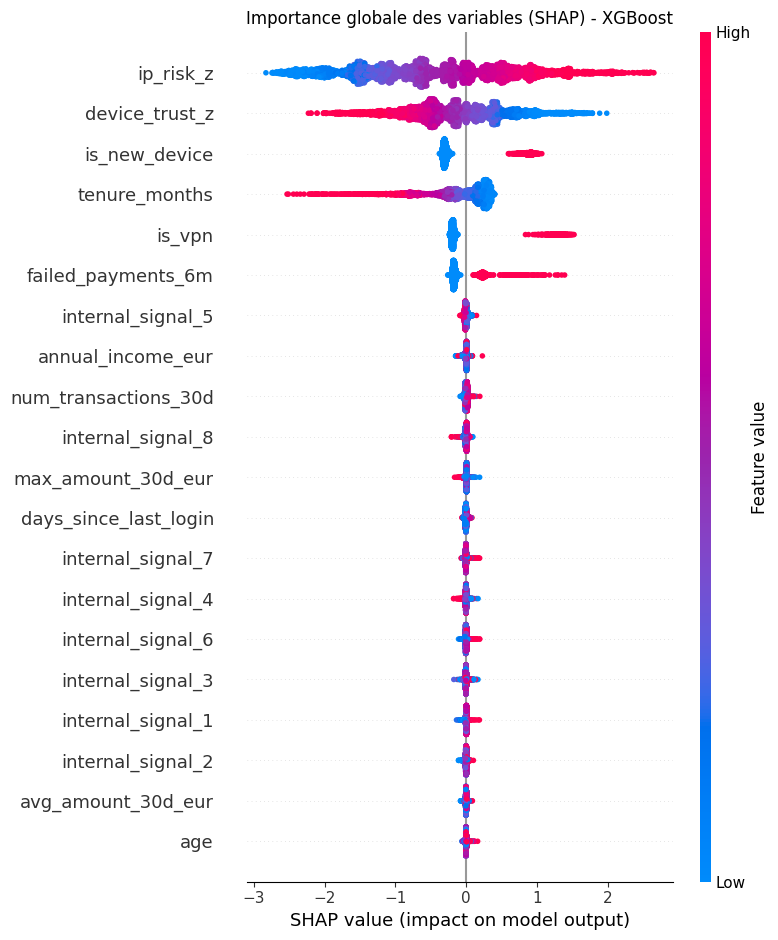

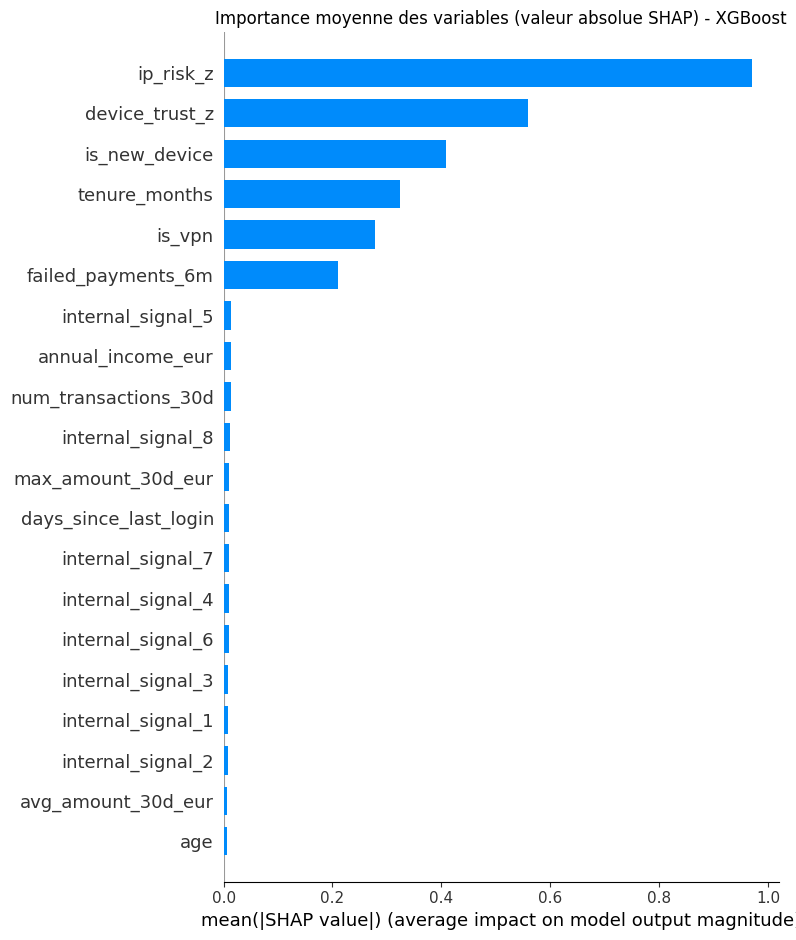

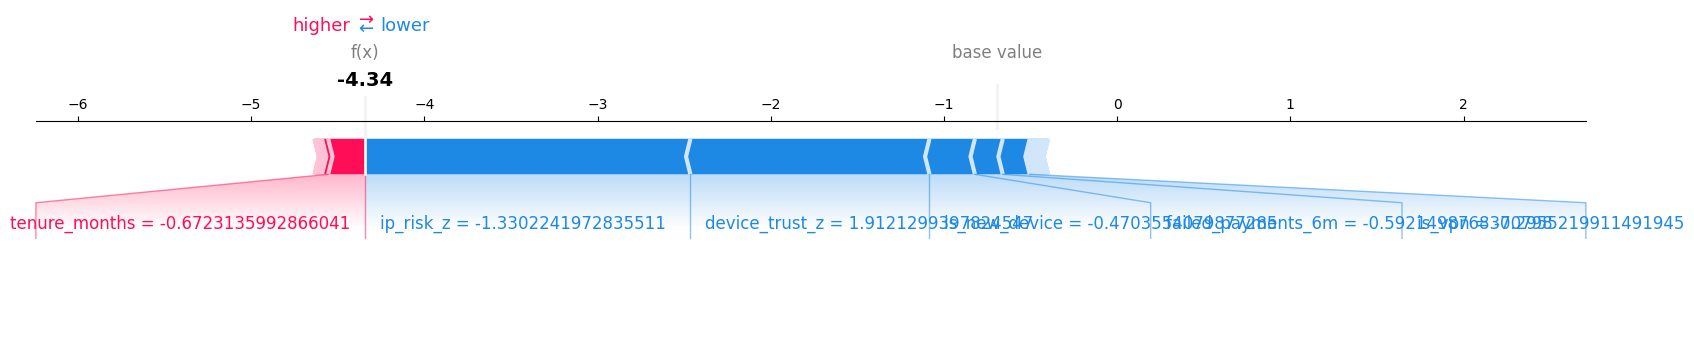

In [ ]:
# Fonction utilitaire pour recharger le dernier modèle XGBoost sauvegardé

def load_latest_xgb_model():
    pattern = "../Models/xgboost_*.pkl"
    files = glob.glob(pattern)
    if not files:
        print(f"Aucun modèle XGBoost trouvé dans ../Models (pattern: {pattern})")
        return None
    latest = max(files, key=os.path.getmtime)
    with open(latest, "rb") as f:
        model = pickle.load(f)
    print(f"Modèle XGBoost chargé depuis {latest}")
    return model


xgb_model_shap = load_latest_xgb_model()

if xgb_model_shap is not None:
    # Charger le mapping feature_i -> nom de feature d'origine
    try:
        mapping = pd.read_csv("../data/feature_mapping_v2_V4.csv")
        # On nettoie les noms pour qu'ils soient lisibles dans les graphes SHAP
        clean_names = mapping["real_name"].str.replace("num__", "", regex=False)
        clean_names = clean_names.str.replace("cat__", "", regex=False)

        # On construit un dict feature_i -> nom propre, puis on applique
        name_map = dict(zip(mapping["feature_col"], clean_names))
        X_val_named = X_val.copy()
        X_val_named.columns = [name_map.get(col, col) for col in X_val_named.columns]
        print("Colonnes de X_val renommées avec les noms de features d'origine (nettoyés).")
    except Exception as e:
        print("Impossible de charger le mapping des features, utilisation des noms 'feature_i' :", e)
        X_val_named = X_val.copy()

    # Pour aller plus vite en SHAP, on peut prendre un échantillon de la validation
    X_val_sample = X_val_named.copy()
    if len(X_val_sample) > 5000:
        X_val_sample = X_val_sample.sample(5000, random_state=42)
        print(f"Sous-échantillonnage de X_val pour SHAP : {X_val_sample.shape}")

    # Explainer SHAP pour modèles de type arbre
    explainer = shap.TreeExplainer(xgb_model_shap)
    shap_values = explainer.shap_values(X_val_sample)

    # 1) Importance globale des features (summary plot)
    plt.figure(figsize=(10, 6))
    shap.summary_plot(
        shap_values,
        X_val_sample,
        feature_names=X_val_sample.columns,
        show=False,
        max_display=20,
    )
    plt.title("Importance globale des variables (SHAP) - XGBoost")
    plt.tight_layout()
    plt.show()

    # 2) Version barplot (plus simple à montrer en présentation)
    plt.figure(figsize=(10, 6))
    shap.summary_plot(
        shap_values,
        X_val_sample,
        feature_names=X_val_sample.columns,
        plot_type="bar",
        show=False,
        max_display=20,
    )
    plt.title("Importance moyenne des variables (valeur absolue SHAP) - XGBoost")
    plt.tight_layout()
    plt.show()

    # 3) Exemple d'explication locale pour un client (première ligne de X_val)
    idx_example = X_val_sample.index[0]
    shap.force_plot(
        explainer.expected_value,
        shap_values[X_val_sample.index.get_loc(idx_example)],
        X_val_sample.loc[idx_example, :],
        matplotlib=True,
    )